# Week 4 — Grouping, stratification, confounding

### Deliverable
- 2 subgroup tables + 2 plots + confounding note


In [1]:
# Core imports (kept minimal for beginners)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Dataset URL (UCI Heart Disease - Cleveland)
UCI_URL = "https://www.archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names for processed.cleveland.data (14 columns commonly used in teaching)
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
        "exang","oldpeak","slope","ca","thal","num"]


In [2]:
import ssl
import io
import urllib.request # Added this import
def load_raw():
    # Create an unverified SSL context to bypass certificate verification
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE

    # Open the URL with the unverified context
    with urllib.request.urlopen(UCI_URL, context=ctx) as url_response:
        # Read the content and decode it
        s = url_response.read().decode('utf-8')

    # Use io.StringIO to make the string behave like a file for pandas.read_csv
    df_raw = pd.read_csv(io.StringIO(s), header=None, names=COLS)
    return df_raw

def coerce_types(df_raw):
    # Missing values are sometimes encoded as "?"
    df = df_raw.replace("?", np.nan).copy()

    # Convert numeric-looking columns
    numeric_cols = ["age","trestbps","chol","thalach","oldpeak","ca","thal","num"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Binary target: disease present if num > 0 (UCI convention)
    df["disease"] = (df["num"] > 0).astype("Int64")
    return df

df_raw = load_raw()
df = coerce_types(df_raw)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


In [3]:
# Minimal cleaning for groupby (you can paste your Week 3 function instead)
def clean_heart(df_raw):
    df = df_raw.replace("?", np.nan).copy()
    numeric_cols = ["age","trestbps","chol","thalach","oldpeak","ca","thal","num"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["disease"] = (df["num"] > 0).astype("Int64")
    return df.dropna(subset=["disease","age","sex","cp"])

df_clean = clean_heart(df_raw)
df_clean.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


## Step 1 — Create age bins


In [4]:
bins = [0, 49, 59, 69, 120]
labels = ["<50", "50-59", "60-69", "70+"]
df_clean["age_bin"] = pd.cut(df_clean["age"], bins=bins, labels=labels, right=True)
df_clean["age_bin"].value_counts(dropna=False)


,count
age_bin,
50-59,125
<50,87
60-69,81
70+,10


## Step 2 — Disease rates by subgroup


In [5]:
overall = df_clean["disease"].mean()
print("Overall disease rate:", overall)

rate_by_sex = df_clean.groupby("sex")["disease"].agg(["mean","count"])
rate_by_age = df_clean.groupby("age_bin")["disease"].agg(["mean","count"])
rate_by_cp  = df_clean.groupby("cp")["disease"].agg(["mean","count"])

display(rate_by_sex)
display(rate_by_age)
display(rate_by_cp)


Overall disease rate: 0.45874587458745875


/tmp/ipykernel_3647/1682995193.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_by_age = df_clean.groupby("age_bin")["disease"].agg(["mean","count"])


,mean,count
sex,,
0.0,0.257732,97
1.0,0.553398,206


,mean,count
age_bin,,
<50,0.298851,87
50-59,0.48,125
60-69,0.604938,81
70+,0.4,10


,mean,count
cp,,
1.0,0.304348,23
2.0,0.18,50
3.0,0.209302,86
4.0,0.729167,144


## Step 3 — Plots (include counts somewhere)


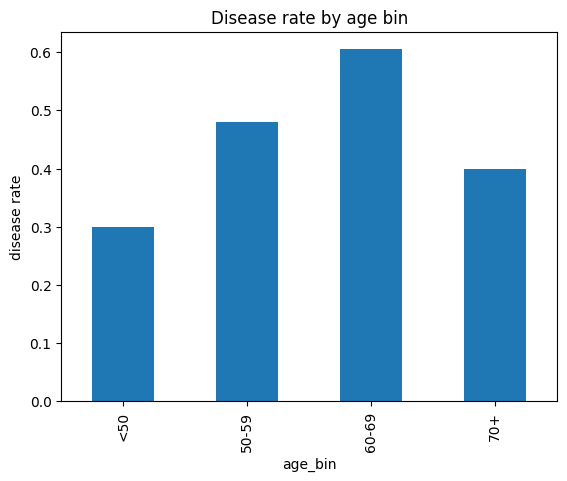

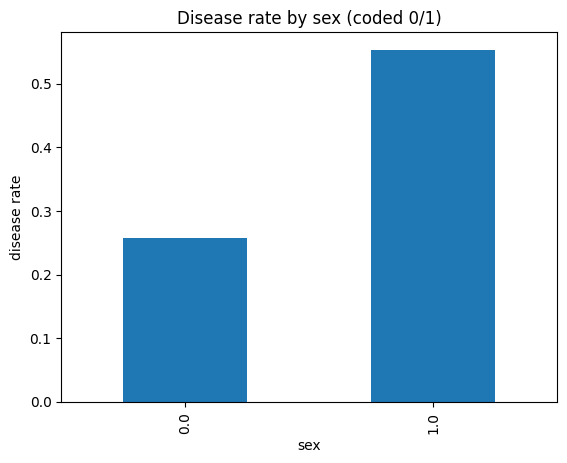

In [6]:
plt.figure()
rate_by_age["mean"].plot(kind="bar")
plt.ylabel("disease rate")
plt.title("Disease rate by age bin")
plt.show()

plt.figure()
rate_by_sex["mean"].plot(kind="bar")
plt.ylabel("disease rate")
plt.title("Disease rate by sex (coded 0/1)")
plt.show()


## TODO — Confounding note
- Relationship you think exists: Males appear to have a higher heart disease rate than females in this dataset. This suggests sex is associated with disease presence.
- Possible confounder: Age is a likely confounder. Males in this dataset tend to be older on average, and age itself is independently associated with higher disease rates. So the apparent sex effect may partly reflect the fact that the male group is older - not that being male alone drives risk.
- How you will probe it (stratify / regression): Stratify by age bin: compute disease rates separately for males and females within each age group (e.g., 50-59, 60-69). If the sex difference shrinks or disappears within age groups, age is confounding the overall sex comparison. A more rigorous approach would be logistic regression with both sex and age as predictors to isolate each variable's independent contribution.
